## 1D Fitting with SASView from notebook
## Peak Voigt hexagonal model — dataset 375

* import all the packages
* install packages before using a separate notebook
* better to work in a dedicated python environnement

In [10]:
import numpy as np

import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
from sasmodels.data import plot_theory

from sasmodels.core import load_model_info
from sasmodels.sasview_model import make_model_from_info

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os

* Configuration of matplotlib for plots

In [11]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

### Load a 1D data file

* load an experimental data file .dat
* define here filename and path on your computer

In [12]:
# raw data file for this notebook (dataset 375)
filenameraw = "./data-examples/PR8_50mM8A2_01294{00000}_AzInt_Px_375.dat"

* subtraction from empty file

In [13]:
fileempty = "./data-examples/Ave_117_water0p05_00011AzInt_Px.dat"

total number of data points:  1208
total empty number of data points:  1208


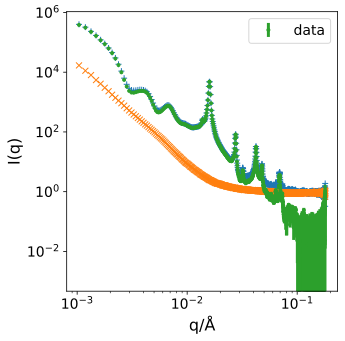

In [14]:
# number of lines in the header (39 '#' lines + 1 column-label line)
skipheader = 47
# header length of the water/empty file (verify against your own file)
skipheader_empty = 27

# Using loadtxt to load data
data_np = np.loadtxt(filenameraw, skiprows=skipheader)

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# datasub incorporates the subtraction of empty file
coeffempty = 1.
empty_np = np.loadtxt(fileempty, skiprows=skipheader_empty)
total_empty_data_number = empty_np.shape[0]
print('total empty number of data points: ', total_empty_data_number)

plt.loglog(empty_np[:,0], coeffempty*empty_np[:,1], 'x')

datasub = sasmodels.data.Data1D(
    x=data_np[0:total_data_number, 0],
    y=data_np[0:total_data_number, 1] - coeffempty*empty_np[0:total_data_number, 1],
    dy=data_np[0:total_data_number, 2])

sasmodels.data.plot_data(datasub)

In [15]:
subfilename = filenameraw[:-4] + '_sub.dat'

with open(subfilename, 'w') as f:
    f.write('raw data file is:' + filenameraw + '\n')
    f.write('number of data points: \t' + str(total_data_number) + '\n')

with open(subfilename, 'a') as fa:
    for i in range(0, total_data_number):
        line_to_write = str(datasub.x[i]) + '\t' + str(datasub.y[i]) + '\t' + str(datasub.dy[i]) + '\n'
        fa.write(line_to_write)

In [16]:
filename = subfilename

Process the data file:
* use `skipheader` to skip the header
* use `skipmin` to skip data points at low q values
  (**important**: `q = 0` makes `(scale_Porod/q)**4 = inf` — always skip it)
* use `skipmax` to skip data points at large q values
* use `slicing_step` to reduce the number of data points
* use `rescale` to convert intensity to cm⁻¹
* use `coeff` to build error bars as a percentage of intensity

total number of data points:  1208
after skip at low and large q values: 688
points removed by cleaning (q<=0 / NaN / I<=0): 0
final number of data points: 172
q > 0: True | y > 0: True | dy > 0: True | all finite: True


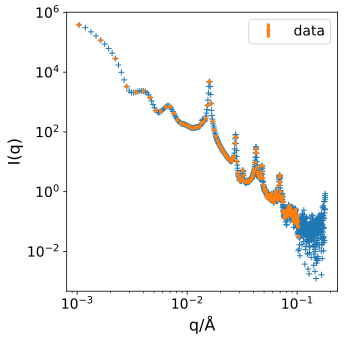

In [17]:
# number of lines in the header
skipheader = 2

# Using loadtxt to load data
data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number = data_np.shape[0]
print('total number of data points: ', total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')

# number of points to skip at low / high q (reference-style trimming)
skipmin = 0
skipmax = 520
number_of_data = total_data_number - skipmax - skipmin
print('after skip at low and large q values:', number_of_data)

# guard: fail loudly if skipmax/skipmin remove everything
if number_of_data <= 0:
    raise ValueError(f'skipmin+skipmax ({skipmin}+{skipmax}) >= data length '
                     f'({total_data_number}); reduce skipmax')

# ---- FAST exploration toggle ----
# True  = quick/approximate run (thinned data, polydispersity off,
#         and prism.py uses a lower Fibonacci count). Flip to False for the final fit.
FAST = True

slicing_step = 4 if FAST else 2   # coarser sampling while exploring

# rescaling of intensity values to cm-1
rescale = 1

# error bars: 10% of intensity values (mirrors reference notebook)
coeff = 0.1

xv = data_np[skipmin:skipmin + number_of_data:slicing_step, 0]
yv = rescale * data_np[skipmin:skipmin + number_of_data:slicing_step, 1]
ev = rescale * coeff * abs(data_np[skipmin:skipmin + number_of_data:slicing_step, 1])


mask = np.isfinite(xv) & (xv > 0) & np.isfinite(yv) & (yv > 0) & np.isfinite(ev) & (ev > 0)
xv, yv, ev = xv[mask], yv[mask], ev[mask]
print('points removed by cleaning (q<=0 / NaN / I<=0):', int(np.sum(~mask)))

data = sasmodels.data.Data1D(x=xv, y=yv, dy=ev)
datasub = sasmodels.data.Data1D(x=xv, y=yv, dy=ev)

number_of_data_new = data.x.shape[0]
print('final number of data points:', number_of_data_new)

# safety check — all four MUST be True before fitting
print('q > 0:', bool(np.all(data.x > 0)),
      '| y > 0:', bool(np.all(data.y > 0)),
      '| dy > 0:', bool(np.all(data.dy > 0)),
      '| all finite:', bool(np.all(np.isfinite(data.y)) and np.all(np.isfinite(data.dy))))

sasmodels.data.plot_data(data)

* plot of the new data set `data`

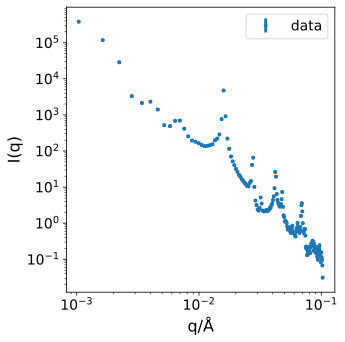

In [18]:
sasmodels.data.plot_data(data)

### save `data` in a new data file
* add `_new` at the end of the name

In [19]:
newfilename = filename[:-4] + '_new.dat'

with open(newfilename, 'w') as f:
    f.write('raw data file is:' + filename + '\n')
    f.write('number of data points: \t' + str(number_of_data_new) + '\n')

with open(newfilename, 'a') as fa:
    for i in range(0, number_of_data_new):
        line_to_write = str(data.x[i]) + '\t' + str(data.y[i]) + '\t' + str(data.dy[i]) + '\n'
        fa.write(line_to_write)

In [20]:
qstart = data.x[0]
print(qstart)

0.001039266634453068


In [21]:
qend = data.x[number_of_data_new-1]
print(qend)

0.10257951877533811


In [22]:
Istart = data.y[0]
print(Istart)

383838.0118367038


In [23]:
Iend = data.y[number_of_data_new-1]
print(Iend)

0.031132122753839142


### fit the data

* create the computation `kernel` selecting the
  `prism+porod_peak_voigt_hexagonal_10peaks+rectangular_prism+peak_voigt` model
  * **A** = `prism` — individual nano-object form factor, regular-polygon cross-section (replaces the former cylinder)
  * **B** = `porod_peak_voigt_hexagonal_10peaks` — Porod term + hexagonal Bragg peaks
  * **C** = `rectangular_prism` — overall assembly shape
  * **D** = `peak_voigt` — single pseudo-Voigt peak for the small low-q form-factor peak
* create the `model` interfaced with bumps module
* create the `experiment`, containing both data and model

In [24]:
model_name = "prism+porod_peak_voigt_hexagonal_10peaks+rectangular_prism+peak_voigt"

In [25]:
kernel = sasmodels.core.load_model(model_name)
params = {}  # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

* default values of all parameters

In [26]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'A_scale': 1.0,
 'A_sld': 126.0,
 'A_sld_solvent': 9.4,
 'A_n_sides': 5,
 'A_radius_average': 500,
 'A_length': 5000,
 'B_scale': 1.0,
 'B_scale_Porod': 0.05,
 'B_a_cell': 900,
 'B_w_f': 0.8,
 'B_hwhm_q10': 1,
 'B_hwhm_q11': 1,
 'B_hwhm_q20': 1,
 'B_hwhm_q21': 1,
 'B_hwhm_q30': 1,
 'B_hwhm_q22': 1,
 'B_hwhm_q31': 1,
 'B_hwhm_q40': 1,
 'B_hwhm_q32': 1,
 'B_hwhm_q41': 1,
 'B_scale_q10': 1,
 'B_scale_q11': 1,
 'B_scale_q20': 1,
 'B_scale_q21': 0,
 'B_scale_q30': 0,
 'B_scale_q22': 0,
 'B_scale_q31': 0,
 'B_scale_q40': 0,
 'B_scale_q32': 0,
 'B_scale_q41': 0,
 'C_scale': 1.0,
 'C_sld': 6.3,
 'C_sld_solvent': 1,
 'C_length_a': 35,
 'C_b2a_ratio': 1,
 'C_c2a_ratio': 1,
 'C_theta': 0,
 'C_phi': 0,
 'C_psi': 0,
 'D_scale': 1.0,
 'D_w_f': 0.8,
 'D_peak_pos': 0.05,
 'D_hwhm_peak': 0.01,
 'up_frac_i': 0.0,
 'up_frac_f': 0.0,
 'up_theta': 90.0,
 'up_phi': 0.0,
 'A_sld_M0': 0.0,
 'A_sld_mtheta': 0.0,
 'A_sld_mphi': 0.0,
 'A_sld_solvent_M0': 0.0,
 'A_sld_solvent_m

#### preliminary step: manual adjustment of parameters before fitting
Don't forget updating the SLD values (x10-6 A-2) !
* silver: 77.9
* water: 9.4

In [27]:
sld_silver = 77.9
sld_water = 9.4

volume_fraction_assembly = 0.5

#estimation of the sld inside the assembly of NRs
sld_assembly=sld_silver*volume_fraction_assembly+sld_water*(1-volume_fraction_assembly)

NR_length = 2300
assembly_length=1e+5 # length of the 1D assembly

# equivalent-disc radius of each nano-object: area = pi * R_ave**2.
# It maps directly onto the former cylinder radius (123.4 A) and is used as
# the prism's radius_average. Adjust to your system.
NR_radius = 123.4

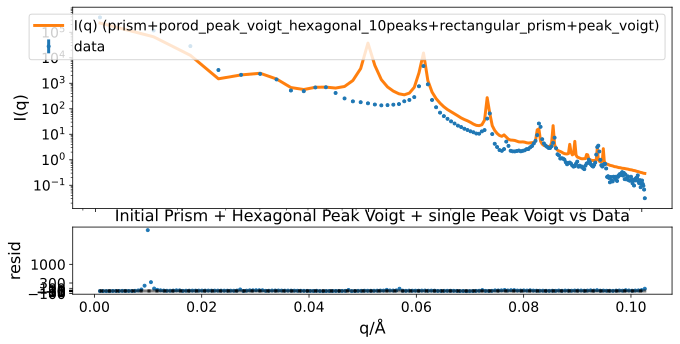

In [40]:
hwhm= 2e-4
params = {
    # --- GLOBAL ---
    "scale": 4e-5 , 
    "background": 0.0, 

    # --- COMPONENT A (prism - individual nano-object form factor) ---
    "A_scale": 1,   # keep equal to one
    "A_sld": sld_silver,
    "A_sld_solvent": sld_water,
    "A_n_sides": 5,                          
    "A_radius_average": NR_radius,           
    "A_length": NR_length,                   
    "A_radius_average_pd_type": 'gaussian',  
    "A_radius_average_pd": 0.075,           
    "A_radius_average_pd_n": 8,              
    "A_radius_average_pd_nsigma": 4,         

    # --- COMPONENT B (Porod + Hexagonal Peak Voigt, 10 peaks) ---
    "B_scale": 1e+9,   # Scaled down
    "B_scale_Porod":0.,
    "B_a_cell": 460.,
    "B_w_f": 0.8,

    "B_hwhm_q10": hwhm,
    "B_hwhm_q11": hwhm,
    "B_hwhm_q20": hwhm,
    "B_hwhm_q21": hwhm,
    "B_hwhm_q30": hwhm,
    "B_hwhm_q22": hwhm,
    "B_hwhm_q31": hwhm,
    "B_hwhm_q40": hwhm,
    "B_hwhm_q32": hwhm,
    "B_hwhm_q41": hwhm,

    
    "B_scale_q10": 0.5,
    "B_scale_q11": 0.01,
    "B_scale_q20": 0.0001,
    "B_scale_q21": 0.001,
    "B_scale_q30": 0.0005,
    
    "B_scale_q22": 1e-4,
    "B_scale_q31": 1e-4,
    "B_scale_q40": 5e-5,
    "B_scale_q32": 5e-5,
    "B_scale_q41": 5e-5,

    # --- COMPONENT C (rectangular_prism for the assembly shape) ---
    "C_scale": 5,
    'C_sld': sld_assembly,
    "C_sld_solvent": sld_water,
    "C_length_a": NR_length,
    "C_length_a_pd_type": 'gaussian', #type of polydispersity function
    "C_length_a_pd": 0.05 , #polydispersity
    "C_length_a_pd_n": 8, #number of steps in polydispersity
    "C_length_a_pd_nsigma": 4, #number of steps in polydispersity

    "C_b2a_ratio": 1, # 1 for a square section
    "C_c2a_ratio": assembly_length/NR_length,

    # --- COMPONENT D (peak_voigt - single low-q form-factor peak) ---
    "D_scale": 1e+9,        
    "D_w_f": 1,
    "D_peak_pos": 0.01,    
    "D_hwhm_peak": hwhm,
      
}

# FAST mode: switch polydispersity off while exploring (big speed-up; re-enable for the final run)
if FAST:
    params['A_radius_average_pd_n'] = 1
    params['C_length_a_pd_n'] = 1

# Build the model and experiment
model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

# Plot the initial guess against your data
plt.figure(figsize=(10, 5))
experiment.plot()
plt.title("Initial Prism + Hexagonal Peak Voigt + single Peak Voigt vs Data")
plt.show()

## Fitting the data — three saved fits

Three fits of increasing complexity are run and **each is saved separately** (`fit1`, `fit2`, `fit3`). Each writes a fitted-curve file `*_<tag>_fit.dat` and a parameter table `*_<tag>_params.txt`.

* **fit1** = A — prism form factor only
* **fit2** = A + B + D — prism + hexagonal Porod/peaks + single peak
* **fit3** = A + B + C + D — all four models

Inactive components are switched off by setting their scale to 0, so the A/B/C/D parameter names stay identical across all fits. `C_sld` and `C_sld_solvent` are kept **constant** (never given a fit range). All 10 hexagonal Bragg peaks are active in B.

> **Speed:** set `FAST = True` (cell above, in the data-loading cell) for quick exploration — it thins the data, turns polydispersity off, and shortens the fits. The prism orientation average is set by `npoints_fibonacci` in `prism.py` (patched to 150; raise back toward 500 for the final accurate run). Flip `FAST = False` for publication-quality fits.

In [45]:
# Helper functions to run and save several fits of increasing complexity.
# Inactive components are switched OFF by zeroing their scale, so the A/B/C/D
# parameter names stay identical across every fit.

fit_results = {}   # tag -> dict(chisq, q, Icalc)

def save_fit(tag, model, experiment, problem, data, base_filename):
    """Save the fitted curve (_<tag>_fit.dat) and the parameter table (_<tag>_params.txt)."""
    n = data.x.shape[0]
    stem = base_filename[:-4] if base_filename.endswith('.dat') else base_filename
    chi2 = problem.chisq()
    Icalc = np.asarray(experiment.Iq_calc)

    fitfile = f"{stem}_{tag}_fit.dat"
    with open(fitfile, 'w') as f:
        f.write('raw data file is:' + base_filename + '\n')
        f.write(f'fit tag: {tag}\tchi2: {chi2}\n')
        for i in range(min(n, len(Icalc))):
            f.write(f"{data.x[i]}\t{Icalc[i]}\n")

    parfile = f"{stem}_{tag}_params.txt"
    with open(parfile, 'w') as f:
        f.write(f"# {tag}  chi2 = {chi2:.6f}\n")
        st = model.state()
        if hasattr(st, 'items'):
            for k, v in st.items():
                f.write(f"{k}\t{v}\n")
        else:
            f.write(str(st) + '\n')

    fit_results[tag] = {'chisq': chi2, 'q': np.array(data.x), 'Icalc': Icalc}
    print(f"[{tag}] chi2 = {chi2:.4f}  ->  saved {fitfile} and {parfile}")
    return fitfile, parfile


def run_fit(tag, active, steps=None):
    """Build a fresh model in which only `active` components contribute, then fit and save it.

    active : subset of {'A','B','C','D'}.  Inactive components are zeroed via their scale.
    """
    if steps is None:
        steps = 60 if FAST else 200        # fewer iterations while exploring
    p = dict(params)                       # start from the manual initial guess (cell above)
    if 'B' not in active: p['B_scale'] = 0.0
    if 'C' not in active: p['C_scale'] = 0.0
    if 'D' not in active: p['D_scale'] = 0.0
    m = sasmodels.bumps_model.Model(model=kernel, **p)

    # the global scale is always fitted
    m.scale.range(1e-5, 1e-4)

    if 'A' in active:                      # prism form factor
        m.A_radius_average.range(80, 200)
        m.A_radius_average_pd.range(0.01, 0.1)
        m.A_length.range(1500, 3000)
        # A_n_sides is an integer cross-section count -> kept fixed, not fitted

    if 'B' in active:                      # Porod + hexagonal peaks: ALL 10 peaks active
        m.B_scale_q10.range(0.1, 1)
        m.B_scale_q11.range(1e-3, 1e-1)
        m.B_scale_q20.range(1e-5, 1e-3)
        m.B_scale_q21.range(1e-4, 1e-2)
        m.B_scale_q30.range(1e-4, 1e-2)
        m.B_scale_q22.range(1e-6, 1e-3)
        m.B_scale_q31.range(1e-6, 1e-3)
        m.B_scale_q40.range(1e-6, 1e-3)
        m.B_scale_q32.range(1e-6, 1e-3)
        m.B_scale_q41.range(1e-6, 1e-3)
        # m.B_a_cell.range(400, 500)       # uncomment to also fit the cell parameter
        # m.B_scale_Porod.range(1e-3, 3e-2)

    if 'C' in active:                      # assembly shape (rectangular_prism)
        m.C_scale.range(0.1, 10.)
        m.C_length_a.range(2000, 2500)
        m.C_length_a_pd.range(0.01, 0.1)
        # C_sld and C_sld_solvent are kept CONSTANT on purpose -> do NOT add a range here

    if 'D' in active:                      # single low-q peak_voigt
        m.D_scale.range(1e-5, 1e-1)
        m.D_peak_pos.range(0.003, 0.02)
        # m.D_hwhm_peak.range(1e-4, 1e-3)

    exp = sasmodels.bumps_model.Experiment(data=data, model=m)
    prob = bumps.fitproblem.FitProblem(exp)
    bumps.fitters.fit(prob, method='lm', steps=steps,
                      ftol=1.5e-06, xtol=1.5e-06, verbose=True)
    save_fit(tag, m, exp, prob, data, filename)
    return m, exp, prob

### Fit 1 — prism (A) only

In [50]:
# Fit 1 : prism form factor only
model1, experiment1, problem1 = run_fit('fit1', {'A'})

step 1 cost 57.358(28)
                                A_length .....|....       2300 in [1500, 3000]
                        A_radius_average ...|......      123.4 in [80, 200]
                     A_radius_average_pd .......|..      0.075 in [0.01, 0.1]
                                   scale ...|......      4e-05 in [1e-05, 0.0001]
step 2 cost 40.534(28)
step 3 cost 40.347(28)
step 4 cost 40.177(28)
step 5 cost 40.176(28)
step 6 cost 40.176(28)
step 7 cost 40.176(28)
step 7 cost 40.176(28) [final]
                                A_length ..|.......    1899.01 in [1500, 3000]
                        A_radius_average ...|......    117.172 in [80, 200]
                     A_radius_average_pd .......|..      0.075 in [0.01, 0.1]
                                   scale .......|.. 7.7714e-05 in [1e-05, 0.0001]
time 8.8 seconds
Fit results for problem: χ² = 40.176(28)
=== Uncertainty from curvature:     name   value(unc.) ===
                                A_length   1899(22)       
  

### Fit 2 — A + B + D

In [51]:
# Fit 2 : prism + hexagonal Porod/peaks + single peak  (no assembly shape)
model2, experiment2, problem2 = run_fit('fit2', {'A', 'B', 'D'})

step 1 cost 101.65(12)
                                A_length .....|....       2300 in [1500, 3000]
                        A_radius_average ...|......      123.4 in [80, 200]
                     A_radius_average_pd .......|..      0.075 in [0.01, 0.1]
                             B_scale_q10 ....|.....        0.5 in [0.1, 1]
                             B_scale_q11 |.........       0.01 in [0.001, 0.1]
                             B_scale_q20 |.........     0.0001 in [1e-05, 0.001]
                             B_scale_q21 |.........      0.001 in [0.0001, 0.01]
                             B_scale_q22 |.........     0.0001 in [1e-06, 0.001]
                             B_scale_q30 |.........     0.0005 in [0.0001, 0.01]
                             B_scale_q31 |.........     0.0001 in [1e-06, 0.001]
                             B_scale_q32 |.........      5e-05 in [1e-06, 0.001]
                             B_scale_q40 |.........      5e-05 in [1e-06, 0.001]
                       

### Fit 3 — all four models (A + B + C + D)

In [52]:
# Fit 3 : all four models together
model3, experiment3, problem3 = run_fit('fit3', {'A', 'B', 'C', 'D'})

step 1 cost 104.29(14)
                                A_length .....|....       2300 in [1500, 3000]
                        A_radius_average ...|......      123.4 in [80, 200]
                     A_radius_average_pd .......|..      0.075 in [0.01, 0.1]
                             B_scale_q10 ....|.....        0.5 in [0.1, 1]
                             B_scale_q11 |.........       0.01 in [0.001, 0.1]
                             B_scale_q20 |.........     0.0001 in [1e-05, 0.001]
                             B_scale_q21 |.........      0.001 in [0.0001, 0.01]
                             B_scale_q22 |.........     0.0001 in [1e-06, 0.001]
                             B_scale_q30 |.........     0.0005 in [0.0001, 0.01]
                             B_scale_q31 |.........     0.0001 in [1e-06, 0.001]
                             B_scale_q32 |.........      5e-05 in [1e-06, 0.001]
                             B_scale_q40 |.........      5e-05 in [1e-06, 0.001]
                       

* fitted values of the full model (fit3) and a $\chi^2$ comparison of the three fits

In [53]:
# Fitted values come from the full model (fit3)
model = model3
experiment = experiment3
problem = problem3

print('A_radius_average =', model.A_radius_average.value)
print('A_length         =', model.A_length.value)
print('A_n_sides        =', model.A_n_sides.value)
print('B_a_cell         =', model.B_a_cell.value)

print('\nchi2 summary:')
for tag in ('fit1', 'fit2', 'fit3'):
    if tag in fit_results:
        print(f'  {tag}: chi2 = {fit_results[tag]["chisq"]:.4f}')

A_radius_average = 123.40000004081232
A_length         = 2299.9999839200937
A_n_sides        = 5.0
B_a_cell         = 460.0

chi2 summary:
  fit1: chi2 = 40.1759
  fit2: chi2 = 101.6500
  fit3: chi2 = 104.2858


### final comparison plot
* data with the three fits overlaid

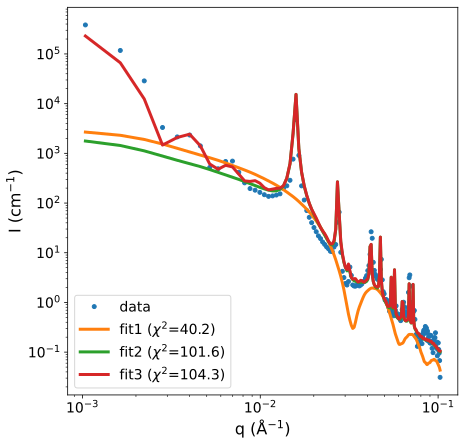

In [54]:
# Overlay the three fits on the data for comparison
plt.figure(figsize=(7, 7))
plt.loglog(data.x, data.y, 'o', ms=4, label='data')
for tag in ('fit1', 'fit2', 'fit3'):
    if tag in fit_results:
        r = fit_results[tag]
        n = min(len(r['q']), len(r['Icalc']))
        plt.loglog(r['q'][:n], r['Icalc'][:n], '-',
                   label=f"{tag} ($\\chi^2$={r['chisq']:.1f})")
plt.xlabel('q ' + r'(Å$^{-1}$)')
plt.ylabel('I ' + r'(cm$^{-1}$)')
plt.legend()
plt.show()